# 数字图像表示与二维卷积实验

素材：`images/outer1.png`（高速公路行车视角照片，960×540，RGB）。

本文件用 percent 格式（jupytext / VS Code / Spyder 通用）编写，因此：
- 直接 `python conv_lab.py` 可以跑完整流程并生成 `outputs/` 里的所有结果；
- 也可以自动转换成 Jupyter Notebook（见 `build_notebook.py`）。

卷积的核心运算完全由 NumPy 手写，**没有**使用 `cv2.filter2D`、
`scipy.signal.convolve2d`、`torch.nn.Conv2d` 等现成实现。

In [1]:
"""图像表示与二维卷积实验：Pillow / NumPy / PyTorch，卷积核心手写实现。"""
from __future__ import annotations

import json
from pathlib import Path

import numpy as np
from PIL import Image

try:
    import torch
except ImportError:  # torch 为可选项
    torch = None

# 路径处理：脚本模式用文件所在目录，Notebook 模式用当前工作目录
try:
    ROOT = Path(__file__).resolve().parent
except NameError:
    ROOT = Path.cwd()

INPUT_IMAGE = ROOT / "images" / "outer1.png"
OUT_DIR = ROOT / "outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# 仅在 Notebook 中内联显示图片；脚本模式下静默
try:
    from IPython.display import Image as IPyImage
    from IPython.display import display as ipy_display
except Exception:
    IPyImage = None
    ipy_display = None


def in_notebook() -> bool:
    try:
        return get_ipython().__class__.__name__ == "ZMQInteractiveShell"  # type: ignore[name-defined]
    except Exception:
        return False


IN_NOTEBOOK = in_notebook()
_LOG: list[str] = []


def log(*parts) -> None:
    """同时打印并收集日志，最后写入 report.txt。"""
    text = " ".join(str(p) for p in parts)
    print(text)
    _LOG.append(text)


def show_image(path: Path) -> None:
    if IN_NOTEBOOK and IPyImage is not None:
        ipy_display(IPyImage(filename=str(path)))

## 1. 数字图像是如何表示的

- 数字图像本质上是一个**数字矩阵**。**像素（pixel）** 就是矩阵里的一个采样点，
  是图像的最小单位；像素上存放的数值表示该点的颜色强度。
- 灰度图：每个像素只有 **1 个数值**（亮度，通常 0=黑，255=白），数组形状 `(H, W)`。
- 彩色图：每个像素有 **3 个数值**（R、G、B 三个通道，各 0–255），数组形状 `(H, W, 3)`。
  RGB 是加色模型，三个通道叠加可以表示约 1677 万种颜色。
- 常见存储类型是 `uint8`（0–255）；做卷积/运算时会先转成浮点（`float32/float64`）避免溢出。
- 灰度图与彩色图的区别：灰度只保留**明暗**信息（1 个通道），彩色额外携带**颜色**信息（3 个通道）。
  彩色转灰度就是按亮度权重 `Y = 0.299R + 0.587G + 0.114B` 把 3 个通道加权求和降成 1 个通道。

In [2]:
# 一个 3x3 的“彩色小图”直观感受一下数据结构：每个像素是 3 个数
tiny = np.array(
    [
        [[255, 0, 0], [0, 255, 0], [0, 0, 255]],   # 红 绿 蓝
        [[255, 255, 0], [0, 0, 0], [255, 255, 255]],  # 黄 黑 白
        [[128, 128, 128], [64, 64, 64], [200, 100, 50]],
    ],
    dtype=np.uint8,
)
log("彩色小图 shape =", tiny.shape, "-> (H=3, W=3, C=3)，3 个像素点各 3 个通道值")
log("灰度小图 shape =", (tiny @ np.array([0.299, 0.587, 0.114])).round().astype(np.uint8).shape,
    "-> (H=3, W=3)，每点只剩 1 个亮度值")

彩色小图 shape = (3, 3, 3) -> (H=3, W=3, C=3)，3 个像素点各 3 个通道值
灰度小图 shape = (3, 3) -> (H=3, W=3)，每点只剩 1 个亮度值


## 2. 把它读成 NumPy 数组和 PyTorch Tensor

- Pillow 打开图像后 `np.asarray(...)` 得到 **HWC** 排列：`(高, 宽, 通道)`。
- PyTorch 习惯 **CHW** 排列：`(通道, 高, 宽)`，用 `permute(2, 0, 1)` 从 HWC 转过来。
- HWC 更贴近“行-列-通道”的直观读写；CHW 让每个通道成为一张完整的二维图，
  便于卷积核在通道维度上整体处理，也是 PyTorch 卷积层要求的输入布局。

In [3]:
img_pil = Image.open(INPUT_IMAGE).convert("RGB")
img_np = np.array(img_pil)                         # HWC, uint8（np.array 会复制，得到可写数组）
H, W, C = img_np.shape

log("Pillow 模式 :", img_pil.mode, " 尺寸(size=W,H):", img_pil.size)
log("NumPy 数组  shape =", img_np.shape, " (H, W, C)")
log("            dtype =", img_np.dtype)
log("            min   =", int(img_np.min()), " max =", int(img_np.max()))

cy, cx = H // 2, W // 2
log(f"中心像素 [y={cy}, x={cx}] 的 RGB =", img_np[cy, cx].tolist(),
    " (即 R,G,B 三个通道值)")
log("左上角像素 [y=0, x=0] 的 RGB =", img_np[0, 0].tolist())

if torch is not None:
    img_tensor_hwc = torch.from_numpy(img_np)                    # (H, W, C) uint8
    img_tensor_chw = img_tensor_hwc.permute(2, 0, 1).contiguous()  # (C, H, W) uint8
    log("")
    log("PyTorch HWC tensor shape =", tuple(img_tensor_hwc.shape), "dtype =", img_tensor_hwc.dtype)
    log("PyTorch CHW tensor shape =", tuple(img_tensor_chw.shape), "dtype =", img_tensor_chw.dtype,
        "-> (C, H, W)")
    log("对应像素 tensor[:, %d, %d] = " % (cy, cx), img_tensor_chw[:, cy, cx].tolist())
    img_tensor_float = img_tensor_chw.float() / 255.0            # 归一化到 0-1，卷积常用
    log("归一化后 dtype =", img_tensor_float.dtype,
        " min =", round(float(img_tensor_float.min()), 4),
        " max =", round(float(img_tensor_float.max()), 4))

Pillow 模式 : RGB  尺寸(size=W,H): (960, 540)
NumPy 数组  shape = (540, 960, 3)  (H, W, C)
            dtype = uint8
            min   = 16  max = 255
中心像素 [y=270, x=480] 的 RGB = [111, 122, 118]  (即 R,G,B 三个通道值)
左上角像素 [y=0, x=0] 的 RGB = [181, 197, 213]

PyTorch HWC tensor shape = (540, 960, 3) dtype = torch.uint8
PyTorch CHW tensor shape = (3, 540, 960) dtype = torch.uint8 -> (C, H, W)
对应像素 tensor[:, 270, 480] =  [111, 122, 118]
归一化后 dtype = torch.float32  min = 0.0627  max = 1.0


### 每个维度 / 数值表示什么，HWC 与 CHW 的区别

`img_np.shape = (540, 960, 3)`：
- `540` → 高度 H，图像的行数（自上而下）。
- `960` → 宽度 W，图像的列数（自左向右）。
- `3`   → 通道 C，依次是 R / G / B。
- 数值 0–255 表示该通道在该点的亮度（`uint8`）。

`img_tensor_chw.shape = (3, 540, 960)`：同一批数据的另一种排布，
- `3` → 通道维放在最前（PyTorch 约定），后两维是 H、W。

**HWC vs CHW**：两者只是内存里轴的顺序不同，数据完全一样。
- NumPy/Pillow 天然是 HWC（读图、显示都按行-列-通道）。
- PyTorch 的卷积/批处理习惯 CHW（或 NCHW），因为这样每个通道是连续的二维平面，
  卷积核按通道整体滑动更自然、访存更高效。
- 互转：`np.transpose(arr, (2, 0, 1))` 或 `torch.permute(t, (2, 0, 1))`。

## 3. 二维卷积的基本过程

- **卷积核（kernel / filter）** 是一个很小的权重矩阵（如 3×3、5×5）。
  它定义了“要看邻域里的什么模式”：全部取平均 → 模糊；中间正、四周负 → 锐化；
  左右/上下做差分 → 边缘检测。
- **怎么移动**：把卷积核当作一个滑动窗口，从图像左上角开始，按 **stride（步长）**
  先向右逐列滑，一行走完再向下滑一行，直到覆盖整幅图。边缘处用 **padding（填充）**
  补像素，决定窗口能否完整覆盖边界。
- **每个位置做什么计算**：取出与卷积核同样大小的一块邻域 patch，把 patch 和卷积核
  **逐元素相乘**，再把所有乘积 **求和**，得到输出图上对应位置的 1 个数值。
  即 `out[y, x] = Σ Σ patch[i, j] * kernel[i, j]`。
  对彩色图，每个通道分别做同样的运算（或按通道加权求和）。
- 所有位置的结果拼起来就是新的**特征图（feature map）**。

## 4. 手写二维卷积（仅 Python + NumPy）

下面提供两个实现：
1. `conv2d`：用“**核加权位移求和**”的等价写法，先 `np.pad` 处理边界，
   再对核里每个权重把整幅图平移相乘后累加——本质就是把卷积定义向量化，速度快。
2. `conv2d_naive`：完全按定义写三重循环（逐输出点、逐核元素），用于验证正确性。

二者结果一致，说明向量化写法遵守的是同一个定义。

In [4]:
def _pad_image(img: np.ndarray, kh: int, kw: int, padding, pad_mode: str, constant: float = 0.0):
    """按 padding 策略补边；返回补边后的图像。"""
    if padding == "valid":
        ph = pw = 0
    elif padding == "same":
        # odd 核时 (k-1)//2 == k//2，保证 stride=1 时输出尺寸不变
        ph, pw = (kh - 1) // 2, (kw - 1) // 2
    else:
        ph = pw = int(padding)

    if ph == 0 and pw == 0:
        return img, ph, pw
    pad_width = ((ph, ph), (pw, pw)) + ((0, 0),) * (img.ndim - 2)
    if pad_mode == "constant":
        padded = np.pad(img, pad_width, mode="constant", constant_values=constant)
    else:
        padded = np.pad(img, pad_width, mode=pad_mode)  # 'reflect' / 'edge' / 'wrap'
    return padded, ph, pw


def conv2d(image, kernel, padding="valid", stride=1, pad_mode="reflect", constant=0.0):
    """手写二维卷积，支持灰度图 (H,W) 和彩色图 (H,W,C)。

    参数
    ----
    image    : ndarray, (H, W) 或 (H, W, C)
    kernel   : ndarray, (kh, kw)
    padding  : 'valid' | 'same' | 整数(对称填充像素数)
    stride   : 滑动步长
    pad_mode : 'reflect' | 'edge' | 'constant'（仅 "same"/整数填充时生效）
    constant : pad_mode='constant' 时的填充值（默认 0）
    """
    img = np.asarray(image, dtype=np.float64)
    kernel = np.asarray(kernel, dtype=np.float64)

    squeeze = False
    if img.ndim == 2:                 # 灰度图补一个通道维，统一按 (H,W,C) 处理
        img = img[:, :, None]
        squeeze = True
    elif img.ndim != 3:
        raise ValueError("image 必须是 (H,W) 或 (H,W,C)")
    if kernel.ndim != 2:
        raise ValueError("kernel 必须是二维矩阵")

    kh, kw = kernel.shape
    padded, _, _ = _pad_image(img, kh, kw, padding, pad_mode, constant)
    Hp, Wp = padded.shape[:2]

    out_h = (Hp - kh) // stride + 1
    out_w = (Wp - kw) // stride + 1
    if out_h <= 0 or out_w <= 0:
        raise ValueError("卷积核比图像还大（或在 valid 下没有有效重叠）")

    # 核心：对核的每个权重 (i,j)，取对应的位移切片并累加 —— 逐元素相乘再求和
    out = np.zeros((out_h, out_w, img.shape[2]), dtype=np.float64)
    for i in range(kh):
        i_end = i + stride * out_h
        for j in range(kw):
            j_end = j + stride * out_w
            window = padded[i:i_end:stride, j:j_end:stride, :]
            out += kernel[i, j] * window

    return out[:, :, 0] if squeeze else out


def conv2d_naive(image, kernel, padding="valid", pad_mode="reflect", stride=1):
    """完全按定义写的三重循环版本（慢），用于验证 conv2d 的正确性。"""
    img = np.asarray(image, dtype=np.float64)
    kernel = np.asarray(kernel, dtype=np.float64)
    squeeze = False
    if img.ndim == 2:
        img = img[:, :, None]
        squeeze = True
    kh, kw = kernel.shape
    padded, _, _ = _pad_image(img, kh, kw, padding, pad_mode)
    Hp, Wp = padded.shape[:2]
    out_h = (Hp - kh) // stride + 1
    out_w = (Wp - kw) // stride + 1
    out = np.zeros((out_h, out_w, img.shape[2]), dtype=np.float64)
    for y in range(out_h):
        for x in range(out_w):
            patch = padded[y * stride:y * stride + kh, x * stride:x * stride + kw, :]
            for a in range(kh):
                for b in range(kw):
                    out[y, x, :] += kernel[a, b] * patch[a, b, :]
    return out[:, :, 0] if squeeze else out


def to_uint8(x: np.ndarray) -> np.ndarray:
    """把浮点结果裁剪/四舍五入回 0–255 的 uint8，方便保存和显示。"""
    return np.clip(np.round(x), 0, 255).astype(np.uint8)


def to_gray(rgb: np.ndarray) -> np.ndarray:
    """RGB -> 灰度，按 Rec.601 亮度权重。"""
    a = np.asarray(rgb, dtype=np.float64)
    return 0.299 * a[..., 0] + 0.587 * a[..., 1] + 0.114 * a[..., 2]


def normalize01(x: np.ndarray) -> np.ndarray:
    x = np.asarray(x, dtype=np.float64)
    lo, hi = x.min(), x.max()
    return (x - lo) / (hi - lo) if hi > lo else np.zeros_like(x)


# 正确性自检：向量化实现 vs 纯循环实现
rng = np.random.default_rng(0)
_probe_img = rng.integers(0, 256, size=(12, 13, 3)).astype(np.float64)
_probe_kernel = rng.normal(size=(3, 3))
_a = conv2d(_probe_img, _probe_kernel, padding="same")
_b = conv2d_naive(_probe_img, _probe_kernel, padding="same")
log("自检：conv2d 与 conv2d_naive 最大差异 =", float(np.abs(_a - _b).max()),
    "（应约为 0）")

自检：conv2d 与 conv2d_naive 最大差异 = 0.0 （应约为 0）


## 5. 常用卷积核与处理结果

使用的卷积核：
- **均值模糊 (3×3)**：所有权重 = 1/9；
- **高斯模糊 (5×5)**：按二维高斯函数生成，中心权重最大，σ=1.0（归一化）；
- **锐化 (3×3)**：`[[0,-1,0],[-1,5,-1],[0,-1,0]]`；
- **边缘检测**：Sobel-X 与 Sobel-Y，并把两方向结果合成为边缘强度图。

In [5]:
MEAN_3x3 = np.ones((3, 3), dtype=np.float64) / 9.0


def gaussian_kernel(size: int = 5, sigma: float = 1.0) -> np.ndarray:
    """按二维高斯函数 g(x,y)=exp(-(x²+y²)/(2σ²)) 生成并归一化的卷积核。"""
    ax = np.arange(size, dtype=np.float64) - (size - 1) / 2.0
    xx, yy = np.meshgrid(ax, ax)
    g = np.exp(-(xx ** 2 + yy ** 2) / (2.0 * sigma ** 2))
    return g / g.sum()


GAUSSIAN_5x5 = gaussian_kernel(5, sigma=1.0)
# 经典整数近似（σ≈1.1，总和 256，便于手算）：
GAUSSIAN_5x5_INT = np.array(
    [[1, 4, 6, 4, 1],
     [4, 16, 24, 16, 4],
     [6, 24, 36, 24, 6],
     [4, 16, 24, 16, 4],
     [1, 4, 6, 4, 1]], dtype=np.float64) / 256.0

SHARPEN_3x3 = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]], dtype=np.float64)
SOBEL_X = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=np.float64)
SOBEL_Y = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]], dtype=np.float64)
LAPLACIAN_3x3 = np.array([[0, 1, 0], [1, -4, 1], [0, 1, 0]], dtype=np.float64)

np.set_printoptions(precision=5, suppress=True, linewidth=120)
log("均值核 (3x3):\n", MEAN_3x3, "\n")
log("高斯核 (5x5, σ=1.0) 由高斯函数生成:\n", GAUSSIAN_5x5, "\n")
log("高斯核 (5x5) 整数近似 /256:\n", GAUSSIAN_5x5_INT)

均值核 (3x3):
 [[0.11111 0.11111 0.11111]
 [0.11111 0.11111 0.11111]
 [0.11111 0.11111 0.11111]] 

高斯核 (5x5, σ=1.0) 由高斯函数生成:
 [[0.00297 0.01331 0.02194 0.01331 0.00297]
 [0.01331 0.05963 0.09832 0.05963 0.01331]
 [0.02194 0.09832 0.1621  0.09832 0.02194]
 [0.01331 0.05963 0.09832 0.05963 0.01331]
 [0.00297 0.01331 0.02194 0.01331 0.00297]] 

高斯核 (5x5) 整数近似 /256:
 [[0.00391 0.01562 0.02344 0.01562 0.00391]
 [0.01562 0.0625  0.09375 0.0625  0.01562]
 [0.02344 0.09375 0.14062 0.09375 0.02344]
 [0.01562 0.0625  0.09375 0.0625  0.01562]
 [0.00391 0.01562 0.02344 0.01562 0.00391]]


In [6]:
# 对彩色图逐通道做“保边”卷积：blur / sharpen 用 reflect 填充 + same，保证尺寸不变
img_f = img_np.astype(np.float64)
mean_blur = conv2d(img_f, MEAN_3x3, padding="same", pad_mode="reflect")
gauss_blur = conv2d(img_f, GAUSSIAN_5x5, padding="same", pad_mode="reflect")
sharpened = conv2d(img_f, SHARPEN_3x3, padding="same", pad_mode="reflect")

# 边缘检测走灰度图
gray_f = to_gray(img_f)
sobel_x = conv2d(gray_f, SOBEL_X, padding="same", pad_mode="reflect")
sobel_y = conv2d(gray_f, SOBEL_Y, padding="same", pad_mode="reflect")
edges = np.hypot(sobel_x, sobel_y)          # 合成边缘强度 sqrt(Gx²+Gy²)

# 统一转成可视化的 uint8
mean_blur_u8 = to_uint8(mean_blur)
gauss_blur_u8 = to_uint8(gauss_blur)
sharpened_u8 = to_uint8(sharpened)
gray_u8 = to_uint8(gray_f)
sobel_x_u8 = to_uint8(normalize01(sobel_x) * 255)
sobel_y_u8 = to_uint8(normalize01(sobel_y) * 255)
edges_u8 = to_uint8(normalize01(edges) * 255)

# 保存单张结果
results = {
    "01_original": img_np,
    "02_mean_blur_3x3": mean_blur_u8,
    "03_gaussian_blur_5x5": gauss_blur_u8,
    "04_sharpen_3x3": sharpened_u8,
    "05_gray": gray_u8,
    "06_sobel_x": sobel_x_u8,
    "07_sobel_y": sobel_y_u8,
    "08_sobel_edges": edges_u8,
}
for name, arr_u8 in results.items():
    Image.fromarray(arr_u8).save(OUT_DIR / f"{name}.png")

log("已保存单张结果到 outputs/：", ", ".join(f"{k}.png" for k in results))

已保存单张结果到 outputs/： 01_original.png, 02_mean_blur_3x3.png, 03_gaussian_blur_5x5.png, 04_sharpen_3x3.png, 05_gray.png, 06_sobel_x.png, 07_sobel_y.png, 08_sobel_edges.png


In [7]:
# 量化对比：用拉普拉斯响应的方差衡量“锐利程度 / 高频能量”
def sharpness_metric(rgb_or_gray) -> float:
    g = to_gray(rgb_or_gray) if np.asarray(rgb_or_gray).ndim == 3 else np.asarray(rgb_or_gray, float)
    lap = conv2d(g, LAPLACIAN_3x3, padding="same", pad_mode="reflect")
    return float(lap.var())


log("")
log("锐利度指标（拉普拉斯方差，越大越锐利 / 高频越多）：")
log(f"  原图          = {sharpness_metric(img_f):12.2f}")
log(f"  均值模糊 3x3  = {sharpness_metric(mean_blur):12.2f}")
log(f"  高斯模糊 5x5  = {sharpness_metric(gauss_blur):12.2f}")
log(f"  锐化 3x3      = {sharpness_metric(sharpened):12.2f}")

summary = {
    "image": {"height": int(H), "width": int(W), "channels": int(C),
              "dtype": str(img_np.dtype), "min": int(img_np.min()), "max": int(img_np.max())},
    "center_pixel_rgb": [int(v) for v in img_np[cy, cx]],
    "center_pixel_yx": [int(cy), int(cx)],
    "tensor_hwc_shape": [int(s) for s in img_tensor_hwc.shape] if torch is not None else None,
    "tensor_chw_shape": [int(s) for s in img_tensor_chw.shape] if torch is not None else None,
    "sharpness_laplacian_var": {
        "original": sharpness_metric(img_f),
        "mean_blur_3x3": sharpness_metric(mean_blur),
        "gaussian_blur_5x5": sharpness_metric(gauss_blur),
        "sharpen_3x3": sharpness_metric(sharpened),
    },
}


锐利度指标（拉普拉斯方差，越大越锐利 / 高频越多）：
  原图          =        60.25
  均值模糊 3x3  =        14.13
  高斯模糊 5x5  =        11.22
  锐化 3x3      =       801.06


## 6. 每种处理为什么会产生这些变化

- **均值模糊**：新像素 = 3×3 邻域 9 个像素的平均值。相邻像素的差异被“抹平”，
  代表细节/噪声/窄边缘的**高频成分被衰减**，只留下整体明暗（低频），所以图变糊、变平滑。
  缺点是把真实边缘也一起模糊了，而且会出现方块感。
- **高斯模糊**：同样是加权平均，但权重来自高斯分布——中心权重最大，离中心越远权重越小。
  它比均值更“柔和自然”，但本质仍是低通滤波，抑制高频 → 变模糊，边缘过渡更平滑、无明显方块感。
- **锐化**：核 `[[0,-1,0],[-1,5,-1],[0,-1,0]]` 可改写成 `原图 + (原图 - 邻域均值)`，
  即 **原图 + 高频（边缘）成分**。它把局部差异放大 → 边缘两侧对比增强、细节更“跳”出来，
  看起来更清晰（同时也会放大噪点）。核系数之和 = 1，保证整体亮度不变。
- **Sobel（X/Y）**：Gx 核把左右两列的像素相减（`-1,0,+1` 列，中间行权重更大），
  Gy 核把上下两行的像素相减。它们近似计算灰度在水平/垂直方向上的**导数（变化率）**：
  平坦区域结果接近 0，边缘处灰度突变 → 梯度值大 → 被检测出来。
  把两方向合成 `sqrt(Gx² + Gy²)` 得到与边缘方向无关的**边缘强度图**，
  于是高速公路上的车道线、护栏、树/天的分界线都会亮起来。

## 7. 不填充（valid）与填充（same）的对比

输出尺寸公式（输入 H、核 K、填充 P、步长 S）：
`out = floor((H + 2P - K) / S) + 1`
- **valid**：P=0，只在能完整放下核的位置计算，输出比输入小（`H - K + 1`），图像边缘像素不会被当作中心。
- **same**：P=(K-1)/2（奇数核），输出和输入同尺寸，边缘也能算，但边缘靠的是**补出来的像素**，
  所以边缘结果会受填充方式影响（reflect 平滑、constant=0 会在边框出现暗边）。

In [8]:
# 用均值核演示 valid 与 same，并比较两种填充模式的边缘差异
same_reflect = conv2d(img_f, MEAN_3x3, padding="same", pad_mode="reflect")
same_zero = conv2d(img_f, MEAN_3x3, padding="same", pad_mode="constant")
valid_out = conv2d(img_f, MEAN_3x3, padding="valid")

log(f"输入尺寸 (H, W)                = ({H}, {W})")
log(f"same  (3x3, P=1, S=1) 输出尺寸 = {same_reflect.shape[:2]}  -> 与输入相同")
log(f"valid (3x3, P=0, S=1) 输出尺寸 = {valid_out.shape[:2]}  -> 每边少 (K-1)=2 像素")

# 边缘一圈像素差异
def border_diff(a, b) -> float:
    k = 2
    d = [
        np.abs(a[:k] - b[:k]).mean(),
        np.abs(a[-k:] - b[-k:]).mean(),
        np.abs(a[:, :k] - b[:, :k]).mean(),
        np.abs(a[:, -k:] - b[:, -k:]).mean(),
    ]
    return float(np.mean(d))


log("")
log("same 下两种填充在边缘一圈的平均绝对差 (reflect vs zero) =", round(border_diff(same_reflect, same_zero), 2))
log("中心区域 reflect vs zero 的平均绝对差                    =",
    round(float(np.abs(same_reflect[10:-10, 10:-10] - same_zero[10:-10, 10:-10]).mean()), 4),
    "（中心几乎不受填充方式影响）")

# 尺寸关系表
log("")
log("卷积核大小 K、填充 P、步长 S 与输出尺寸的关系（H=540 为例，P 指单边）：")
log(f"{'K':>3} {'S':>3} {'P(valid/same)':>16} {'out(valid)':>12} {'out(same)':>12} {'公式核对':>8}")
for K in (3, 5, 7):
    for S in (1, 2):
        p_same = (K - 1) // 2
        out_v = (H + 2 * 0 - K) // S + 1
        out_s = (H + 2 * p_same - K) // S + 1
        log(f"{K:>3} {S:>3} {('0 / '+str(p_same)):>16} {out_v:>12} {out_s:>12} {'OK':>8}")

输入尺寸 (H, W)                = (540, 960)
same  (3x3, P=1, S=1) 输出尺寸 = (540, 960)  -> 与输入相同
valid (3x3, P=0, S=1) 输出尺寸 = (538, 958)  -> 每边少 (K-1)=2 像素

same 下两种填充在边缘一圈的平均绝对差 (reflect vs zero) = 21.28
中心区域 reflect vs zero 的平均绝对差                    = 0.0 （中心几乎不受填充方式影响）

卷积核大小 K、填充 P、步长 S 与输出尺寸的关系（H=540 为例，P 指单边）：
  K   S    P(valid/same)   out(valid)    out(same)     公式核对
  3   1            0 / 1          538          540       OK
  3   2            0 / 1          269          270       OK
  5   1            0 / 2          536          540       OK
  5   2            0 / 2          268          270       OK
  7   1            0 / 3          534          540       OK
  7   2            0 / 3          267          270       OK


### 结论：卷积核 / 填充 / 步长 与输出尺寸的关系

- **核越大**：same 下输出尺寸不变（靠加大填充维持），但 valid 下输出会明显变小，且边缘被裁掉更多。
- **填充 P 越大**：输出越大；P=(K-1)/2 时 same 输出与输入等高。
- **步长 S 越大**：输出约按 1/S 缩小（滑过的位置变少），当 S>1 时 same 也不一定与输入同尺寸。
- 统一公式：`out = floor((H + 2P - K) / S) + 1`（宽同理）。

已保存对比拼图: 09_comparison_grid.png


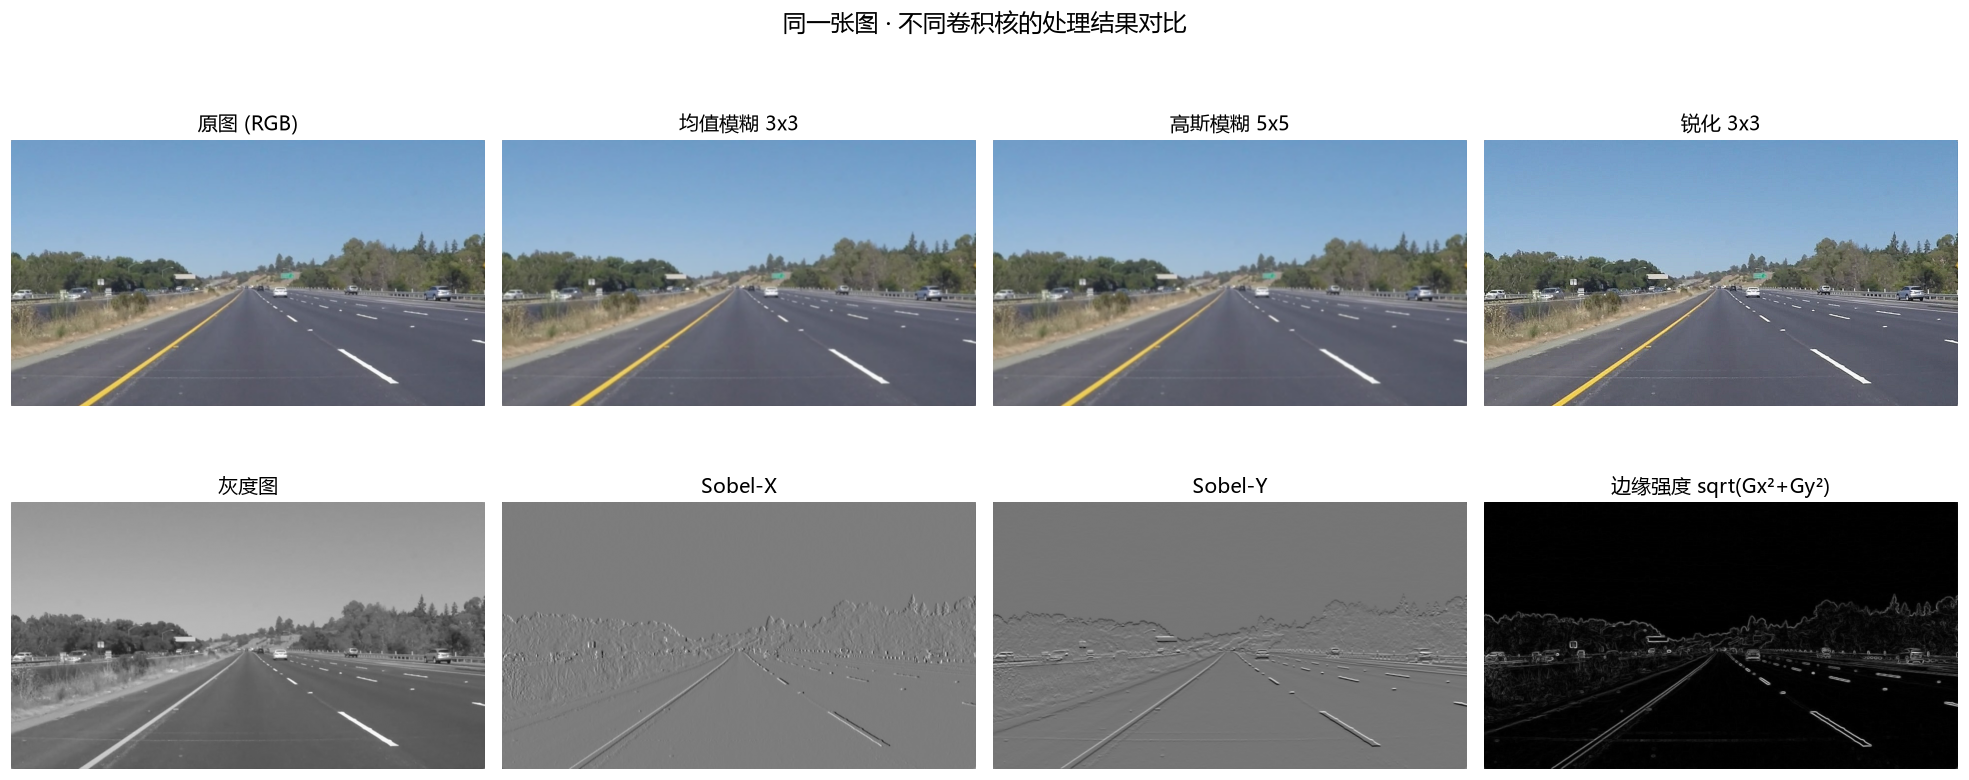

In [9]:
# 结果拼图：原图 + 四种处理放到一起比较
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib import font_manager

# 让图上能显示中文标题
for _font_path in (r"C:\Windows\Fonts\msyh.ttc", r"C:\Windows\Fonts\simhei.ttf"):
    if Path(_font_path).exists():
        try:
            font_manager.fontManager.addfont(_font_path)
        except Exception:
            pass
matplotlib.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "DejaVu Sans"]
matplotlib.rcParams["axes.unicode_minus"] = False

def save_grid(panels, path, ncols=4, figsize=(18, 8), suptitle=None):
    n = len(panels)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    axes = np.atleast_1d(axes).ravel()
    for ax, (title, image) in zip(axes, panels):
        ax.imshow(image, cmap="gray" if image.ndim == 2 else None, vmin=0, vmax=255)
        ax.set_title(title, fontsize=13)
        ax.axis("off")
    for ax in axes[n:]:
        ax.axis("off")
    if suptitle:
        fig.suptitle(suptitle, fontsize=16)
    fig.tight_layout()
    fig.savefig(path, dpi=110, bbox_inches="tight")
    plt.close(fig)
    return path


grid_path = save_grid(
    [
        ("原图 (RGB)", img_np),
        ("均值模糊 3x3", mean_blur_u8),
        ("高斯模糊 5x5", gauss_blur_u8),
        ("锐化 3x3", sharpened_u8),
        ("灰度图", gray_u8),
        ("Sobel-X", sobel_x_u8),
        ("Sobel-Y", sobel_y_u8),
        ("边缘强度 sqrt(Gx²+Gy²)", edges_u8),
    ],
    OUT_DIR / "09_comparison_grid.png",
    ncols=4,
    figsize=(18, 8),
    suptitle="同一张图 · 不同卷积核的处理结果对比",
)
log("已保存对比拼图:", grid_path.name)
show_image(grid_path)

已保存 padding 对比图: 10_padding_valid_vs_same.png


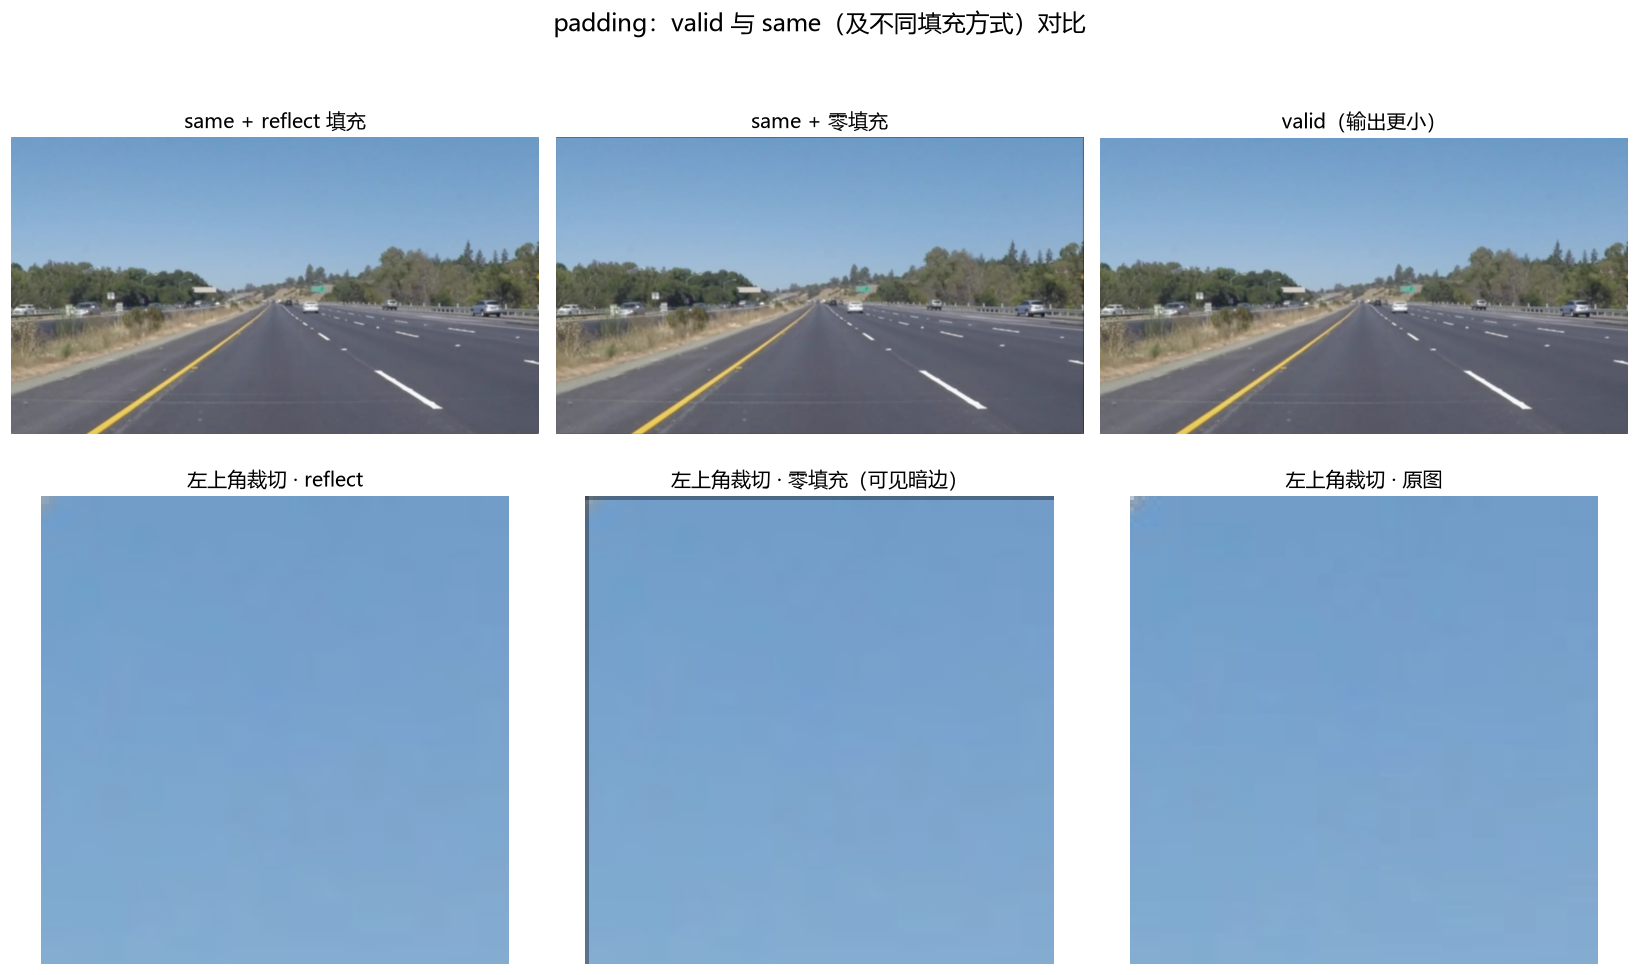

In [10]:
# valid vs same 可视化：整图 + 左上角 120x120 放大，观察边缘像素变化
crop = 120
pad_grid_path = save_grid(
    [
        ("same + reflect 填充", to_uint8(same_reflect)),
        ("same + 零填充", to_uint8(same_zero)),
        ("valid（输出更小）", to_uint8(valid_out)),
        ("左上角裁切 · reflect", to_uint8(same_reflect[:crop, :crop])),
        ("左上角裁切 · 零填充（可见暗边）", to_uint8(same_zero[:crop, :crop])),
        ("左上角裁切 · 原图", img_np[:crop, :crop]),
    ],
    OUT_DIR / "10_padding_valid_vs_same.png",
    ncols=3,
    figsize=(15, 9),
    suptitle="padding：valid 与 same（及不同填充方式）对比",
)
log("已保存 padding 对比图:", pad_grid_path.name)
show_image(pad_grid_path)

In [11]:
# 写出结构化结果，方便复用
(OUT_DIR / "results.json").write_text(
    json.dumps(summary, indent=2, ensure_ascii=False), encoding="utf-8"
)
log("已写出 outputs/results.json")
log("关键数值：", json.dumps(summary["sharpness_laplacian_var"], ensure_ascii=False))

# report.txt：把上面所有打印内容落盘
(OUT_DIR / "report.txt").write_text("\n".join(_LOG) + "\n", encoding="utf-8")
print("\n[done] 所有结果已写入 outputs/")

已写出 outputs/results.json
关键数值： {"original": 60.24705710223261, "mean_blur_3x3": 14.12892864888568, "gaussian_blur_5x5": 11.219452374485522, "sharpen_3x3": 801.0552903441665}

[done] 所有结果已写入 outputs/
